# Individual homework project 1

In [3]:
# Import modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
# Import data

customers = pd.read_csv("data/customers.csv")
transactions = pd.read_csv("data/transactions.csv")
sessions = pd.read_csv("data/web_sessions.csv")
campaigns = pd.read_csv("data/marketing_campaigns.csv")

### Specific questions

Q1. What is the average purchase value for customers from Spain?

In [5]:
merged_tc = pd.merge(customers, transactions, on='customer_id', how='left')
spain_cust = merged_tc[merged_tc['country'] == 'Spain']

avg_purchase_spain = spain_cust['purchase_value'].mean()

print(f"The average purchase value for customers from Spain is: ${avg_purchase_spain:.2f}")



The average purchase value for customers from Spain is: $75.63


Q2. What is the minimum purchase value for customers from Germany?

In [6]:
germany_cust = merged_tc[merged_tc['country'] == 'Germany']

min_purchase_germany = germany_cust['purchase_value'].min()
print(f"The minimun purchase value for customers from Germany is: ${min_purchase_germany:.2f}")


The minimun purchase value for customers from Germany is: $0.39


Q3. How much did males spend on buying products in the Sports category?

In [7]:
is_male_sports = (merged_tc['gender'] == 'Male') & (merged_tc['product_category'] == 'sports')

male_sports_f = merged_tc[is_male_sports]

total_male_spend_sport = male_sports_f['purchase_value'].sum()

print(f"The total spent by males in sport is: ${total_male_spend_sport}")

The total spent by males in sport is: $191184.72


Q4. What is the average age of female customers from Canada?

In [8]:
is_canada_female = (merged_tc['country'] == 'Canada') & (merged_tc['gender'] == 'Female')

canada_female = merged_tc[is_canada_female]

avgage_female_canada = canada_female['age'].mean()

print(f"The average age of female customers from Canada is: {avgage_female_canada:.2f}")



The average age of female customers from Canada is: 43.09


Q5. How much does an average male customer from the UK spend?

In [9]:
is_UK_male = (merged_tc['country'] == 'UK') & (merged_tc['gender'] == 'Male')

UK_male = merged_tc[is_UK_male]

avg_purchase_UK_male = UK_male['purchase_value'].mean()

print(f"The average purchase value for male customers from the UK is: ${avg_purchase_UK_male:.2f}")

The average purchase value for male customers from the UK is: $76.63


Q6. What is the maximum purchase value for females in the Toys category?

In [10]:
is_toys_female = (merged_tc['product_category'] == 'toys') & (merged_tc['gender'] == 'Female')

toys_female = merged_tc[is_toys_female]

max_purchase_fem_toys = toys_female['purchase_value'].max()

print(f"The maximum purchase value for females in toys is: ${max_purchase_fem_toys:.2f}")


The maximum purchase value for females in toys is: $423.84


Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [11]:
converted_sessions = sessions[sessions['converted'] == 1]

#total page views per customer
pages_per_customer = converted_sessions.groupby('customer_id')['pages_viewed'].sum()

#average across customers
avg_pages_converted = pages_per_customer.mean()

print(f"The average number of pages viewed for customers who made a purchase is {avg_pages_converted:.2f}")

The average number of pages viewed for customers who made a purchase is 8.75


Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [26]:
#total time per customer
time_per_customer = sessions.groupby(['customer_id','converted'])['time_on_site'].sum().reset_index()

#average per segment
avg_time = time_per_customer.groupby('converted')['time_on_site'].mean()

avg_converted = avg_time.loc[1]
avg_non_converted = avg_time.loc[0]

print(f"Purchasing customers spent on site {avg_converted:.2f} seconds on average, while non-purchasing customers spent {avg_non_converted:.2f} seconds on average")

Purchasing customers spent on site 475.13 seconds on average, while non-purchasing customers spent 1827.56 seconds on average


### Visualisation tasks

Q9. Plot purchasing value across years.

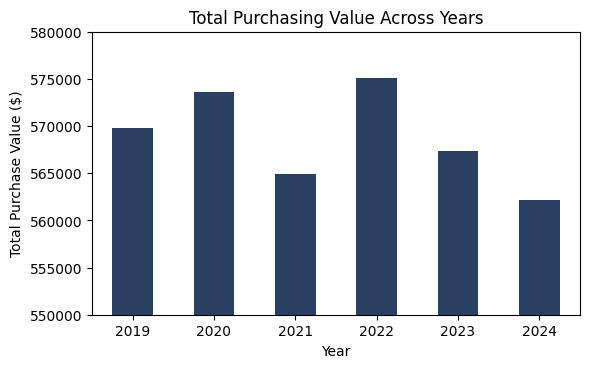

In [13]:
#Ensure 'purchase_date' is in the correct datetime format
transactions['purchase_date'] = pd.to_datetime(transactions['purchase_date'])

#Extract the year into a new column
transactions['purchase_year'] = transactions['purchase_date'].dt.year

#Group by the year and sum the purchase values
yearly_sales = transactions.groupby('purchase_year')['purchase_value'].sum()

#Create the plot
yearly_sales.plot(kind='bar',color ='#2a4063', figsize=(6,4))

plt.style.use('seaborn-v0_8-deep')
plt.ylim(550000, 580000) 
plt.title('Total Purchasing Value Across Years', fontsize=12)
plt.xlabel('Year',fontsize=10)
plt.ylabel('Total Purchase Value ($)',fontsize=10)
plt.tight_layout()
plt.xticks(rotation=0) 
 
plt.show()


Q10. Plot purchasing value across product categories.

In [12]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


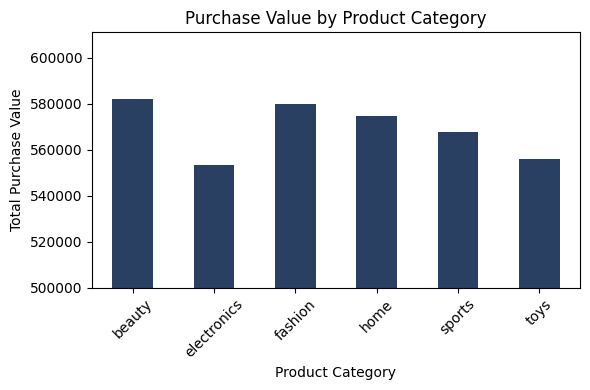

In [14]:
category_sales = transactions.groupby('product_category')['purchase_value'].sum()
category_sales.plot(kind='bar')

category_sales.plot(kind='bar', color ='#2a4063', figsize=(6,4))
plt.ylim(bottom = 500000)
plt.title('Purchase Value by Product Category',fontsize = 12)
plt.xlabel('Product Category', fontsize = 10)
plt.ylabel('Total Purchase Value', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion

Pattern 1.: Channel quality - Total Revenue by Acquisition Channel


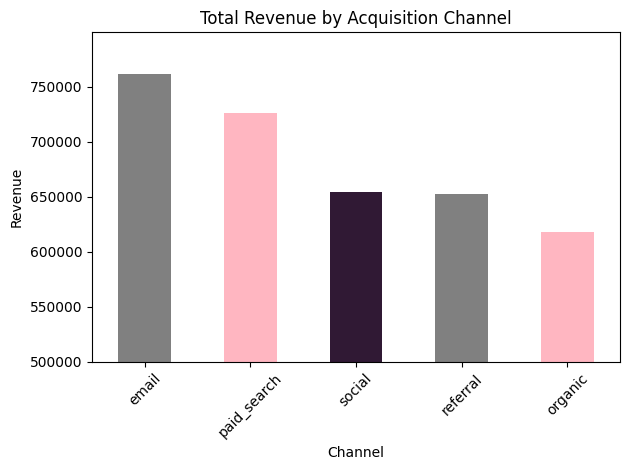

In [15]:
print("Pattern 1.: Channel quality - Total Revenue by Acquisition Channel")

merged_tc['acquisition_channel'] = merged_tc['acquisition_channel'].str.lower()

channel_revenue = (
    merged_tc.groupby('acquisition_channel')['purchase_value']
    .sum()
    .sort_values(ascending=False)
)
my_colors = ['grey', '#FFB6C1', '#301934']
channel_revenue.plot(kind='bar',color= my_colors)
plt.ylim(bottom = 500000)
plt.title("Total Revenue by Acquisition Channel",fontsize=12)
plt.ylabel("Revenue",fontsize=10)
plt.xlabel("Channel",fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
print(channel_revenue)

acquisition_channel
email          761439.08
paid_search    726397.58
social         654061.49
referral       652936.94
organic        618086.59
Name: purchase_value, dtype: float64


In [17]:
print("Pattern 2. Segmentation Analysis - Creating age groups on customers and aggregate revenue by age group to identify trends")

Pattern 2. Segmentation Analysis - Creating age groups on customers and aggregate revenue by age group to identify trends


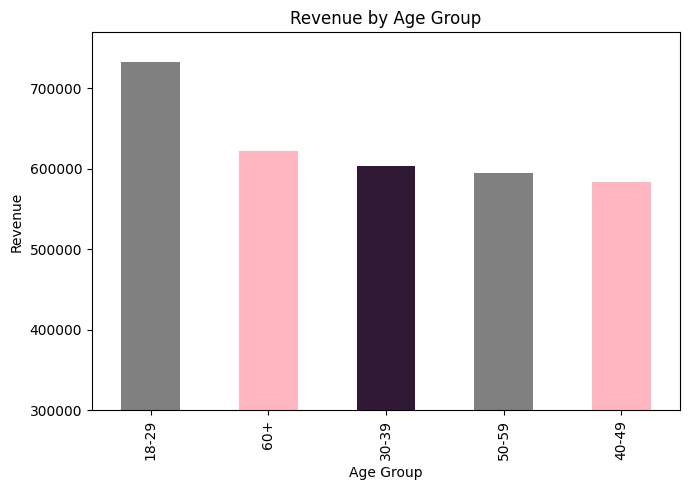

In [17]:
#create age groups on customers
bins = [18, 30, 40, 50, 60, 70]
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, right=False)

#merge customers with transactions 
tc = transactions.merge(customers[['customer_id','age_group']], on='customer_id', how='left')

#aggregate revenue by age group
age_revenue = tc.groupby('age_group')['purchase_value'].sum().sort_values(ascending=False)

#plot
my_colors = ['grey', '#FFB6C1', '#301934']
age_revenue.plot(kind='bar', color=(my_colors),figsize=(7,5))
plt.ylim(bottom = 300000)
plt.title("Revenue by Age Group",fontsize=12)
plt.ylabel("Revenue",fontsize=10)
plt.xlabel("Age Group",fontsize=10)
plt.tight_layout()
plt.show()

In [19]:
print(age_revenue)

age_group
18-29    732494.49
60+      622408.82
30-39    603508.38
50-59    594189.17
40-49    583202.35
Name: purchase_value, dtype: float64


In [20]:
#Count unique IDs per age group 
active_customers = tc.groupby('age_group')['customer_id'].nunique().sort_values(ascending=False)

print(active_customers)

age_group
18-29    2095
60+      1787
30-39    1746
40-49    1733
50-59    1719
Name: customer_id, dtype: int64


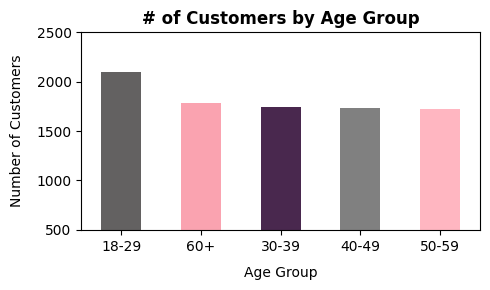

In [21]:
custom_colors = ["#636161", "#FAA3B0", "#49284E", '#808080', '#FFB6C1']

#Create Plot for # of customers
plt.figure(figsize=(5, 3))
active_customers.plot(kind='bar', color=custom_colors, linewidth=1)

plt.ylim(500, 2500)
plt.title("# of Customers by Age Group", fontsize=12, fontweight='bold')
plt.ylabel("Number of Customers", fontsize=10, labelpad=9)
plt.xlabel("Age Group", fontsize=10, labelpad=9)
plt.xticks(rotation=0) 
plt.tight_layout()

plt.show()

In [22]:
print("Pattern 3. Conversion Ratio - proportion of Converted and Non-Converted and group by traffic source")

Pattern 3. Conversion Ratio - proportion of Converted and Non-Converted and group by traffic source


In [23]:
#Calculate proportions (this gives values between 0 and 1)
conversion_proportions = sessions['converted'].value_counts(normalize=True)

#Multiply by 100 to get percentages
conversion_percentages = (conversion_proportions * 100).round(2)

#Rename index 
conversion_percentages.index = conversion_percentages.index.map({0: 'Non-Converted', 1: 'Converted'})
print(conversion_percentages)

converted
Non-Converted    86.91
Converted        13.09
Name: proportion, dtype: float64


<Axes: >

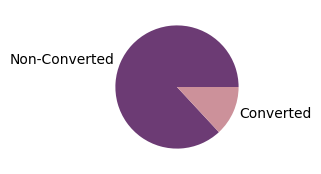

In [24]:

conversion_percentages.plot.pie(y=conversion_percentages, figsize = (4,2), colors= ['#6c3b74','#cc919a'])

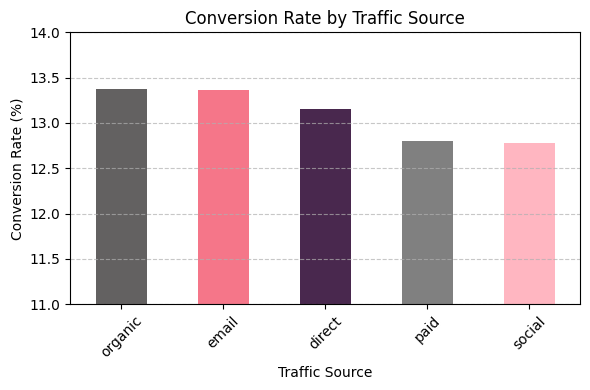

traffic_source
organic    13.38
email      13.36
direct     13.15
paid       12.80
social     12.78
Name: converted, dtype: float64


In [25]:
#Calculate the rate
conversion_rate = (
    sessions.groupby('traffic_source')['converted']
    .mean()
    .sort_values(ascending=False)
) * 100  
conversion_rate = conversion_rate.round(2)

#Create the plot
custom_colors = ["#636161FF", "#F57689", "#49284E", '#808080', '#FFB6C1']
conversion_rate.plot(kind='bar', figsize =(6,4), color= custom_colors)
plt.ylim(11, 14)
plt.title('Conversion Rate by Traffic Source', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=10)
plt.xlabel('Traffic Source', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(conversion_rate)

In [26]:
'''
Insights:
1. Email is the highest-performing acquisition channel by total revenue, outperforming Organic and suggesting
that the direct communication to customers is currently the most effective marketing campaign.
While Email leads in total revenue, the Organic channel represents an area for growth,
improving our search engine rankings could increase this 'free' revenue stream without increasing our advertising budget.

2. The 18-29 age group is our primary revenue engine, leading both in total spend and customer volume. 
Since the rankings are identical, that means that higher revenue in certain segments is probably a result 
of having more customers in those brackets rather than higher individual spending.   

3. With nearly 87% of sessions currently resulting in no purchase, there is a massive opportunity to scale revenue by identifying
and removing the friction points that prevent this vast majority of users from converting.

4. Conversion rates are remarkably consistent across all channels (ranging from 12.78% to 13.38%),
indicating that the website's ability to close a sale is highly stable regardless of how a visitor finds us.
      
5. Since conversion rates are the same, we don't need to worry about channel quality as much,
we should simply focus on which channel can give the highest volume of traffic for the lowest cost.  
'''


"\nInsights:\n1. Email is the highest-performing acquisition channel by total revenue, outperforming Organic and suggesting\nthat the direct communication to customers is currently the most effective marketing campaign.\nWhile Email leads in total revenue, the Organic channel represents an area for growth,\nimproving our search engine rankings could increase this 'free' revenue stream without increasing our advertising budget.\n\n2. The 18-29 age group is our primary revenue engine, leading both in total spend and customer volume. \nSince the rankings are identical, that means that higher revenue in certain segments is probably a result \nof having more customers in those brackets rather than higher individual spending.   \n\n3. With nearly 87% of sessions currently resulting in no purchase, there is a massive opportunity to scale revenue by identifying\nand removing the friction points that prevent this vast majority of users from converting.\n\n4. Conversion rates are remarkably cons